In [11]:
import pandas as pd

df_original = pd.read_parquet("dataset_calidad.parquet")
df_simple = pd.read_parquet("simple")
df_intermedio = pd.read_parquet("intermedio")
df_avanzado = pd.read_parquet("avanzado")

datasets = {
    "Original": df_original,
    "Simple": df_simple,
    "Intermedio": df_intermedio,
    "Avanzado": df_avanzado
}

print("Datasets cargados correctamente")

Datasets cargados correctamente


In [12]:
columnas_temp = ['categoria_esperada', 'monto_calculado']

for name, df_temp in datasets.items():
    for col in columnas_temp:
        if col in df_temp.columns:
            df_temp.drop(columns=[col], inplace=True)

print("Columnas temporales eliminadas")

Columnas temporales eliminadas


In [13]:
import numpy as np

cols_duplicados = ['id_transaccion', 'fecha', 'cliente_id', 'producto', 'cantidad']

def get_quality_metrics(df):
    existing_cols = [col for col in cols_duplicados if col in df.columns]

    return {
        "registros": len(df),
        "nulos": df.isnull().sum().sum(),
        "duplicados": df.duplicated(subset=existing_cols).sum() if existing_cols else 0,
        "precios_invalidos": (df['precio_unitario'] <= 0).sum() if 'precio_unitario' in df else 0,
        "descuentos_invalidos": (df['descuento'] > 1).sum() if 'descuento' in df else 0,
        "cantidades_invalidas": (df['cantidad'] <= 0).sum() if 'cantidad' in df else 0
    }

In [14]:
base_size = len(df_original)

comparison = []

for name, df_temp in datasets.items():
    metrics = get_quality_metrics(df_temp)

    comparison.append({
        "Dataset": name,
        "Registros": metrics["registros"],
        "Pérdida (%)": round((base_size - metrics["registros"]) / base_size * 100, 2),
        "Nulos": metrics["nulos"],
        "Duplicados": metrics["duplicados"],
        "Precios inválidos": metrics["precios_invalidos"],
        "Descuentos inválidos": metrics["descuentos_invalidos"],
        "Cantidades inválidas": metrics["cantidades_invalidas"]
    })

comparison_df = pd.DataFrame(comparison)

display(comparison_df)

,Dataset,Registros,Pérdida (%),Nulos,Duplicados,Precios inválidos,Descuentos inválidos,Cantidades inválidas
0,Original,1000025,0.00,30,0,8,5,2
1,Simple,999965,0.01,0,0,0,0,0
2,Intermedio,490812,50.92,0,0,0,0,0
3,Avanzado,1000017,0.00,0,0,0,0,0


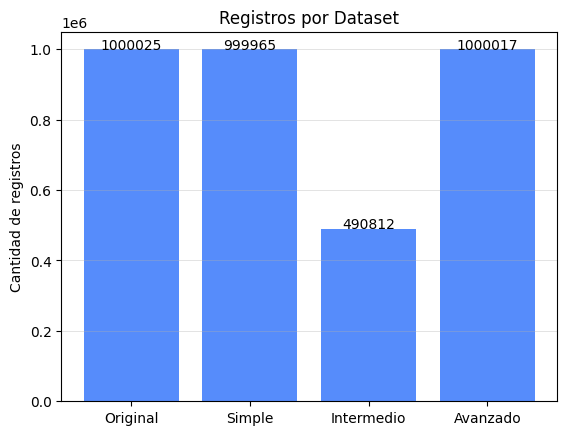

In [15]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(comparison_df["Dataset"], comparison_df["Registros"])
plt.title("Registros por Dataset")
plt.ylabel("Cantidad de registros")
plt.grid(axis='y')

for i, v in enumerate(comparison_df["Registros"]):
    plt.text(i, v, str(v), ha='center')

plt.show()

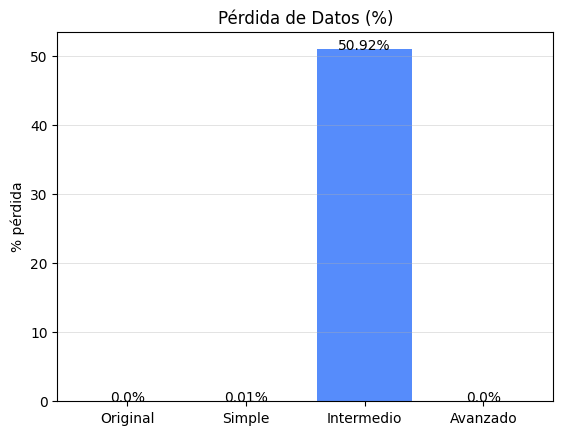

In [16]:
plt.figure()
plt.bar(comparison_df["Dataset"], comparison_df["Pérdida (%)"])
plt.title("Pérdida de Datos (%)")
plt.ylabel("% pérdida")
plt.grid(axis='y')

for i, v in enumerate(comparison_df["Pérdida (%)"]):
    plt.text(i, v, f"{v}%", ha='center')

plt.show()

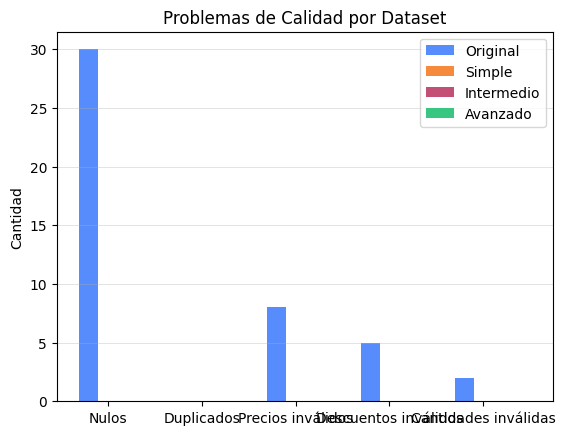

In [17]:
problemas_cols = [
    "Nulos",
    "Duplicados",
    "Precios inválidos",
    "Descuentos inválidos",
    "Cantidades inválidas"
]

x = np.arange(len(problemas_cols))
width = 0.2

plt.figure()

for i, (name, df_temp) in enumerate(datasets.items()):
    metrics = get_quality_metrics(df_temp)
    values = [
        metrics["nulos"],
        metrics["duplicados"],
        metrics["precios_invalidos"],
        metrics["descuentos_invalidos"],
        metrics["cantidades_invalidas"]
    ]
    plt.bar(x + i*width, values, width, label=name)

plt.xticks(x + width, problemas_cols)
plt.title("Problemas de Calidad por Dataset")
plt.ylabel("Cantidad")
plt.legend()
plt.grid(axis='y')

plt.show()

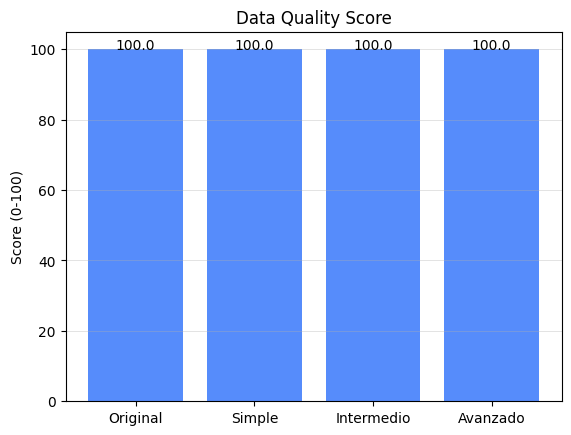

In [18]:
def quality_score(metrics, total_rows):
    issues = (
        metrics["nulos"] +
        metrics["duplicados"] +
        metrics["precios_invalidos"] +
        metrics["descuentos_invalidos"] +
        metrics["cantidades_invalidas"]
    )

    score = max(0, 100 - (issues / total_rows * 100))
    return round(score, 2)


scores = []

for name, df_temp in datasets.items():
    m = get_quality_metrics(df_temp)
    score = quality_score(m, m["registros"])
    scores.append(score)

plt.figure()
plt.bar(datasets.keys(), scores)
plt.title("Data Quality Score")
plt.ylabel("Score (0-100)")
plt.grid(axis='y')

for i, v in enumerate(scores):
    plt.text(i, v, str(v), ha='center')

plt.show()